
# UK Soft Drinks Industry Levy: An Interrupted Time Series Analysis

### 1. Hypothesis and Research Question 

This notebook examines whether there is evidence that the introduction of the UK Soft Drinks Industry Levy (SDIL) in April 2018 is associated with a change in household expenditure on soft drinks. 

The SDIL is a tax levied on manufacturers of soft drinks with high sugar content, introduced with the aim of reducing sugar consumption through higher prices and incentives for product reformulation.

Household expenditure on soft drinks is used as the outcome of interest because it captures the combined effects of multiple adjustment channels following the policy introduction. Changes in expenditure may reflect variations in prices, quantities purchased, or shifts in product composition resulting from reformulation. As such, expenditure provides a broad measure of how households’ spending behaviour responds to the levy, although it does not allow for direct inference about changes in sugar consumption.

The analysis adopts an interrupted time series (ITS) framework, treating the introduction of the SDIL as a policy intervention in an otherwise continuous quarterly expenditure trend. The identifying assumption is that, in the absence of the policy, soft drinks expenditure would have continued to evolve according to its pre‑intervention trajectory. Evidence consistent with a policy effect would therefore take the form of a discrete change in the level of expenditure, a change in its underlying growth trend, or both, coinciding with the implementation of the SDIL.

Research question:
Did the introduction of the UK Soft Drinks Industry Levy in April 2018 lead to a change in the level or trend of household expenditure on soft drinks relative to its pre‑policy trajectory?

### 2.Hypothesis
Under this framework, the null hypothesis is that the introduction of the Soft Drinks Industry Levy had no effect on household expenditure on soft drinks. This implies that there is neither a discrete change in the level of expenditure at the time of the policy introduction nor a change in the underlying trend relative to the pre‑intervention period.

The alternative hypothesis is that the introduction of the levy is associated with a deviation from the pre‑policy trajectory. This may take the form of an immediate change in the level of expenditure, a change in the post‑intervention growth rate, or both. Rejection of the null hypothesis therefore indicates evidence consistent with a policy effect, while failure to reject the null hypothesis suggests that expenditure continued to follow its pre‑intervention trend.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
df = pd.read_csv("../data/raw/consumer_trends_soft_drinks.csv")
df.head()
df.columns

Index(['Title', '01.2.2 Non-alcoholic beverages Mineral water and soft drinks CP NSA £m'], dtype='str')

In [4]:

df.shape

(212, 2)

### 3. Data Preparation

The original dataset contains long, descriptive column names. These are renamed for readability and ease of use in code.

In [5]:

#rename columns
df = df.rename(columns={
    "Title": "period",
    "01.2.2 Non-alcoholic beverages Mineral water and soft drinks CP NSA £m": "soft_drinks_expenditure_m"
})



The raw dataset contains non-time rows (e.g. notes and metadata).  
We only keep rows that correspond to valid time periods (years or quarters) using a regular expression.

In [6]:

#remove meta data rows
mask_time = df["period"].astype(str).str.match(r"^\d{4}(\sQ[1-4])?$", na=False)
df_time = df.loc[mask_time].copy()


In [7]:

#keep only quarterly data
df_q = df_time[df_time["period"].astype(str).str.contains(r"\sQ[1-4]$", regex=True)].copy()


In [8]:
#convert quarter to datetime 
df_q["soft_drinks_expenditure_m"] = pd.to_numeric(df_q["soft_drinks_expenditure_m"], errors="coerce")

In [9]:
#check missing values
df_q["soft_drinks_expenditure_m"].isna().sum()

np.int64(0)

In [10]:
df_q["year"] = df_q["period"].str[:4].astype(int)
df_q["quarter"] = df_q["period"].str.extract(r"Q([1-4])")[0].astype(int)

df_q["date"] = (
    pd.PeriodIndex(
        df_q["year"].astype(str) + "Q" + df_q["quarter"].astype(str),
        freq="Q"
    )
    .to_timestamp()
)

df_q["soft_drinks_expenditure_m"] = pd.to_numeric(
    df_q["soft_drinks_expenditure_m"],
    errors="coerce"
)

df_q = df_q.sort_values("date").set_index("date")

In [11]:

df_q.head()

,period,soft_drinks_expenditure_m,year,quarter
date,,,,
1985-01-01,1985 Q1,368,1985,1
1985-04-01,1985 Q2,524,1985,2
1985-07-01,1985 Q3,522,1985,3
1985-10-01,1985 Q4,502,1985,4
1986-01-01,1986 Q1,404,1986,1


### 4. Exploratory analysis


This section provides a descriptive overview of quarterly household expenditure on soft drinks over time. The analysis is exploratory in nature and does not attempt to identify causal effects. Its purpose is to document long‑run trends, seasonal patterns, and any apparent deviations in the data, and to motivate the subsequent interrupted time series (ITS) analysis.

Figure 1 plots quarterly soft drinks expenditure from 1985 to 2025. The series exhibits a strong upward long‑run trend, indicating sustained growth in nominal household spending on soft drinks over time. In addition, a pronounced and persistent seasonal pattern is evident, with systematic within‑year fluctuations that repeat across years. These features suggest that short‑run movements in expenditure may be driven by seasonal factors and broader long‑term spending trends, rather than discrete structural changes alone.


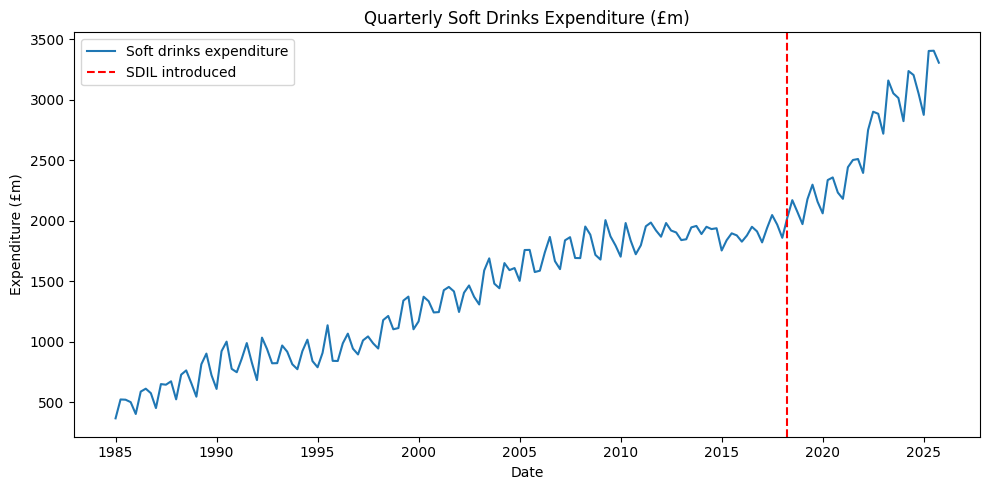

In [12]:

plt.figure(figsize=(10, 5))

plt.plot(
    df_q.index,
    df_q["soft_drinks_expenditure_m"],
    label="Soft drinks expenditure"
)
plt.axvline(pd.Timestamp("2018-04-01"), color="red", linestyle="--", label="SDIL introduced")

plt.title("Quarterly Soft Drinks Expenditure (£m)")
plt.xlabel("Date")
plt.ylabel("Expenditure (£m)")
plt.legend()

plt.tight_layout()
plt.show()


While Figure 1 provides valuable context, the length of the time series makes it difficult to assess behaviour immediately surrounding the introduction of the Soft Drinks Industry Levy (SDIL) in April 2018. In particular, any potential change in the level or slope of expenditure at the policy date may be obscured by strong trend growth and regular seasonal variation.

To examine the dynamics further, Figure 2 presents a zoomed‑in view of the period from 2015 to 2022. The narrower window will allow for clearer visual assessment of pre-policy trends and any deviations coinciding with the implementation of the levy. 

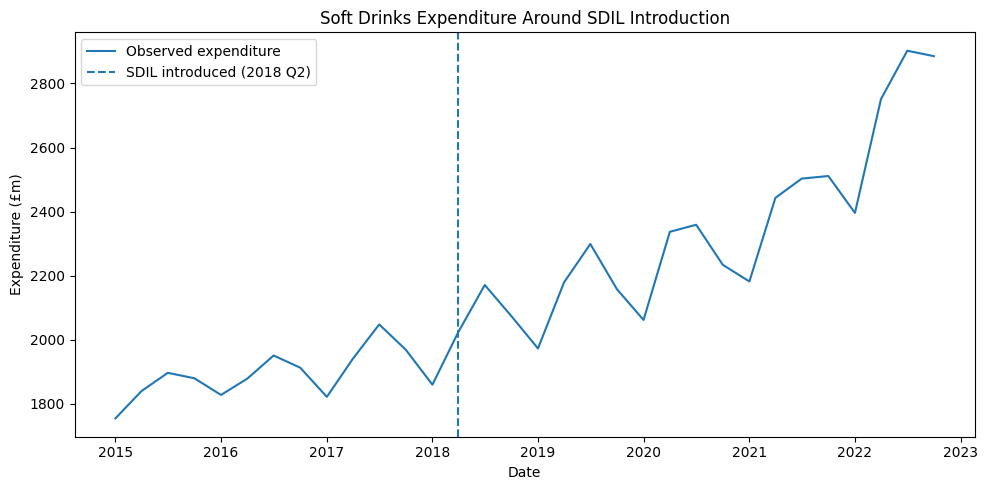

In [13]:
policy_date = pd.Timestamp("2018-04-01")

# Define zoom window
df_zoom = df_q.loc["2015-01-01":"2022-12-31"]

plt.figure(figsize=(10, 5))

plt.plot(
    df_zoom.index,
    df_zoom["soft_drinks_expenditure_m"],
    label="Observed expenditure",
)

plt.axvline(
    policy_date,
    linestyle="--",
    label="SDIL introduced (2018 Q2)"
)

plt.xlabel("Date")
plt.ylabel("Expenditure (£m)")
plt.title("Soft Drinks Expenditure Around SDIL Introduction")
plt.legend()

plt.tight_layout()
plt.show()

Over this shorter window in Figure 2, expenditure continues to follow an upward trajectory with clear seasonal fluctuations, and no clear visual break is apparent at the time of the SDIL’s introduction. The absence of an obvious discontinuity suggests that any policy effect, if present, is likely to be subtle rather than large and immediate.

However, visual inspection alone is insufficient to detect statistically meaningful changes in either the level or underlying growth rate of the series, particularly in the presence of strong seasonality and long‑run trend growth. As a result, descriptive evidence from the plots cannot be used to draw firm conclusions regarding the impact of the levy. For this reason, the analysis proceeds by estimating an interrupted time series model, which formalises the pre‑policy trajectory and allows for statistical testing of changes in the level and trend of expenditure associated with the introduction of the SDIL.

### 5. ITS

To assess whether the introduction of the Soft Drinks Industry Levy (SDIL) is associated with a change in household expenditure on soft drinks, the analysis employs an interrupted time series (ITS) regression framework. This approach estimates deviations from a pre‑intervention trend following the implementation of a clearly defined policy intervention.

The intervention date is set to April 2018, which is the introduction of the SDIL. Quarterly data are used throughout, providing a sufficiently long pre‑intervention period to establish the underlying trend in expenditure and a substantial post‑intervention period to assess potential changes.

The ITS model includes three key explanatory variables:

A linear time trend, denoted $t$, which captures the underlying secular growth in soft drinks expenditure over time.
A post‑intervention indicator, denoted $post$, which takes the value 1 for quarters from 2018 Q2 onwards and 0 otherwise. The coefficient on this variable captures any immediate, discrete change in the level of expenditure coinciding with the policy introduction.
An interaction term between time and the post‑intervention indicator, denoted $t_{post}$​, which measures the change in the slope of the expenditure trend following the introduction of the levy. This term allows the growth rate of expenditure to differ between the pre‑ and post‑policy periods.



In [14]:
# ITS variables

policy_date = pd.Timestamp("2018-04-01")

# Linear time trend
df_q["t"] = range(len(df_q))

# Post-policy indicator
df_q["post"] = (df_q.index >= policy_date).astype(int)

# Time since policy introduction
policy_t = df_q.index.get_loc(policy_date)
df_q["t_post"] = (df_q["t"] - policy_t) * df_q["post"]

In [15]:
df_q.loc["2017-01-01":"2019-12-31",
         ["soft_drinks_expenditure_m", "t", "post", "t_post"]]


,soft_drinks_expenditure_m,t,post,t_post
date,,,,
2017-01-01,1822,128,0,0
2017-04-01,1941,129,0,0
2017-07-01,2048,130,0,0
2017-10-01,1969,131,0,0
2018-01-01,1860,132,0,0
2018-04-01,2025,133,1,0
2018-07-01,2171,134,1,1
2018-10-01,2074,135,1,2
2019-01-01,1973,136,1,3


Under this specification, the coefficient on the time trend represents the average quarterly change in expenditure prior to the SDIL, while the coefficients on the post‑intervention dummy and the interaction term capture deviations from this pre‑policy trajectory. A statistically significant coefficient on the post‑intervention indicator would indicate an immediate shift in expenditure levels, whereas a statistically significant coefficient on the interaction term would indicate a change in the post‑policy growth rate.

The model is estimated using ordinary least squares (OLS). Given the quarterly frequency of the data and the potential for serial correlation in expenditure over time, heteroskedasticity and autocorrelation‑consistent (HAC) standard errors are also reported as a robustness measure. This ensures valid statistical inference in the presence of autocorrelated residuals.

It is important to emphasise that identification relies on the assumption that, absent the SDIL, household soft drinks expenditure would have continued to follow its pre‑intervention trend. While this assumption cannot be directly tested, the long pre‑policy period and stability of the trend prior to 2018 provide support for its plausibility. Within this framework, statistically significant changes in the level or slope of expenditure following the intervention are interpreted as evidence consistent with an association between the SDIL and household spending on soft drinks.

In [16]:

X = sm.add_constant(df_q[["t", "post", "t_post"]])
y = df_q["soft_drinks_expenditure_m"]

model = sm.OLS(y, X).fit()
print(model.summary())


                                OLS Regression Results                               
Dep. Variable:     soft_drinks_expenditure_m   R-squared:                       0.964
Model:                                   OLS   Adj. R-squared:                  0.963
Method:                        Least Squares   F-statistic:                     1416.
Date:                       Fri, 17 Apr 2026   Prob (F-statistic):          6.27e-115
Time:                               12:09:50   Log-Likelihood:                -1036.8
No. Observations:                        164   AIC:                             2082.
Df Residuals:                            160   BIC:                             2094.
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [17]:

nw_model = model.get_robustcov_results(
    cov_type="HAC",
    maxlags=4   # quarterly data
)
print(nw_model.summary())


                                OLS Regression Results                               
Dep. Variable:     soft_drinks_expenditure_m   R-squared:                       0.964
Model:                                   OLS   Adj. R-squared:                  0.963
Method:                        Least Squares   F-statistic:                     1300.
Date:                       Fri, 17 Apr 2026   Prob (F-statistic):          4.47e-112
Time:                               12:09:50   Log-Likelihood:                -1036.8
No. Observations:                        164   AIC:                             2082.
Df Residuals:                            160   BIC:                             2094.
Df Model:                                  3                                         
Covariance Type:                         HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------


## Residual diagnostics (model checking)

To assess whether the ITS regression provides reliable inference, I examine the model residuals. 
Quarterly time-series data often exhibit serial correlation (residuals persisting over time), which can make conventional OLS standard errors overly optimistic. 
These diagnostics help motivate the use of heteroskedasticity and autocorrelation-consistent (HAC/Newey–West) standard errors reported in the results.


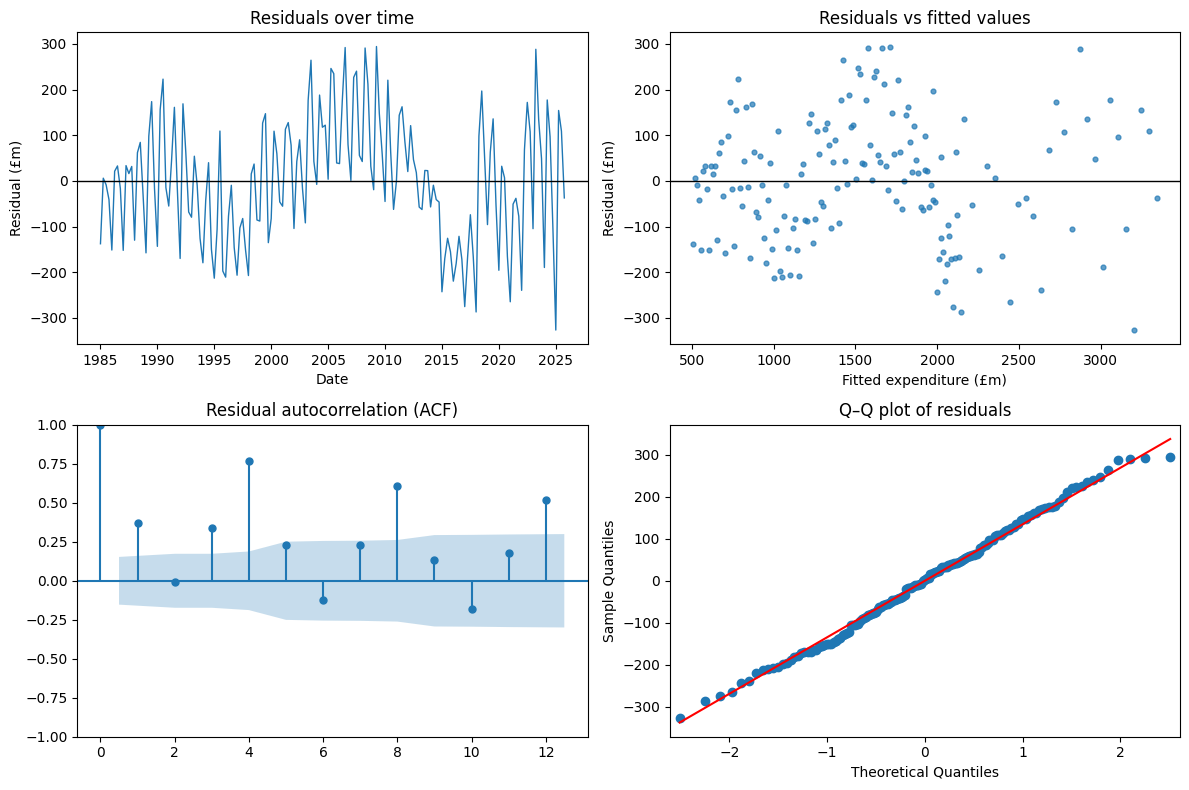

In [ ]:
from statsmodels.graphics.gofplots import qqplot 

# --- Residuals from the OLS ITS model
resid = model.resid
fitted = model.fittedvalues

# --- Create a 2x2 diagnostics panel
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (1) Residuals over time
axes[0, 0].plot(df_q.index, resid, linewidth=1)
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Residuals over time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Residual (£m)")

# (2) Residuals vs fitted (checks non-linearity / heteroskedasticity)
axes[0, 1].scatter(fitted, resid, s=12, alpha=0.7)
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Residuals vs fitted values")
axes[0, 1].set_xlabel("Fitted expenditure (£m)")
axes[0, 1].set_ylabel("Residual (£m)")

# (3) ACF plot (serial correlation)
sm.graphics.tsa.plot_acf(resid, lags=12, ax=axes[1, 0])
axes[1, 0].set_title("Residual autocorrelation (ACF)")

# (4) Q-Q plot (normality check)
sm.qqplot(resid, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q–Q plot of residuals")


plt.tight_layout()
plt.show()

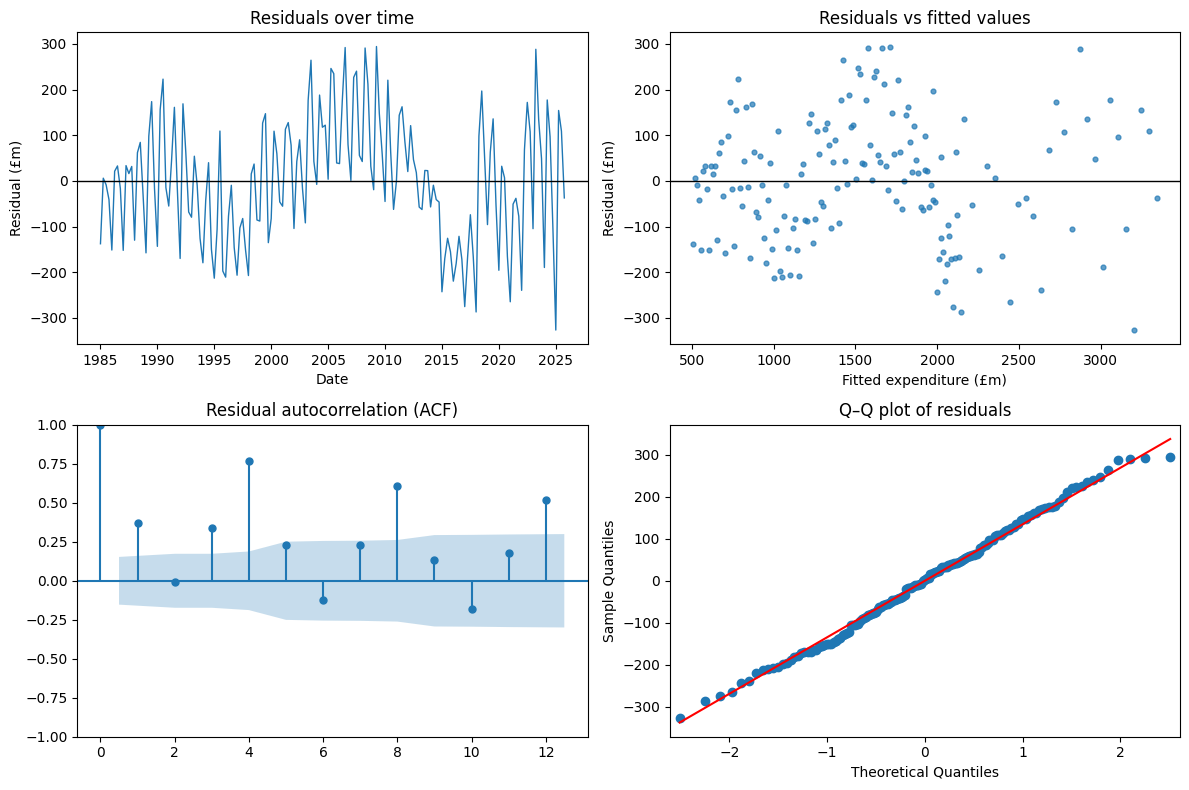

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

# --- Residuals from the OLS ITS model
resid = pd.Series(model.resid).dropna()
fitted = pd.Series(model.fittedvalues).loc[resid.index]  # align with resid index

# --- Create a 2x2 diagnostics panel
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (1) Residuals over time
axes[0, 0].plot(resid.index, resid, linewidth=1)
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Residuals over time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Residual (£m)")

# (2) Residuals vs fitted
axes[0, 1].scatter(fitted, resid, s=12, alpha=0.7)
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Residuals vs fitted values")
axes[0, 1].set_xlabel("Fitted expenditure (£m)")
axes[0, 1].set_ylabel("Residual (£m)")

# (3) ACF plot (serial correlation)
sm.graphics.tsa.plot_acf(resid, lags=12, ax=axes[1, 0])
axes[1, 0].set_title("Residual autocorrelation (ACF)")

# (4) Q-Q plot (normality check)
sm.qqplot(resid, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q–Q plot of residuals")

plt.tight_layout()
plt.show()


Regression tables can be difficult to interpret at a glance, so we will visualise the ITS model by constructing a counterfactual series: an estimate of what soft drinks expenditure would have looked like if the pre‑policy trend had continued unchanged after April 2018.

This plot overlays:
- the observed quarterly expenditure,
- the ITS fitted values (from the full model), and
- the counterfactual projection (pre‑policy trend extrapolated forward).

The distance between the observed series and the counterfactual provides an intuitive view of the estimated level change and any post‑policy trend divergence.

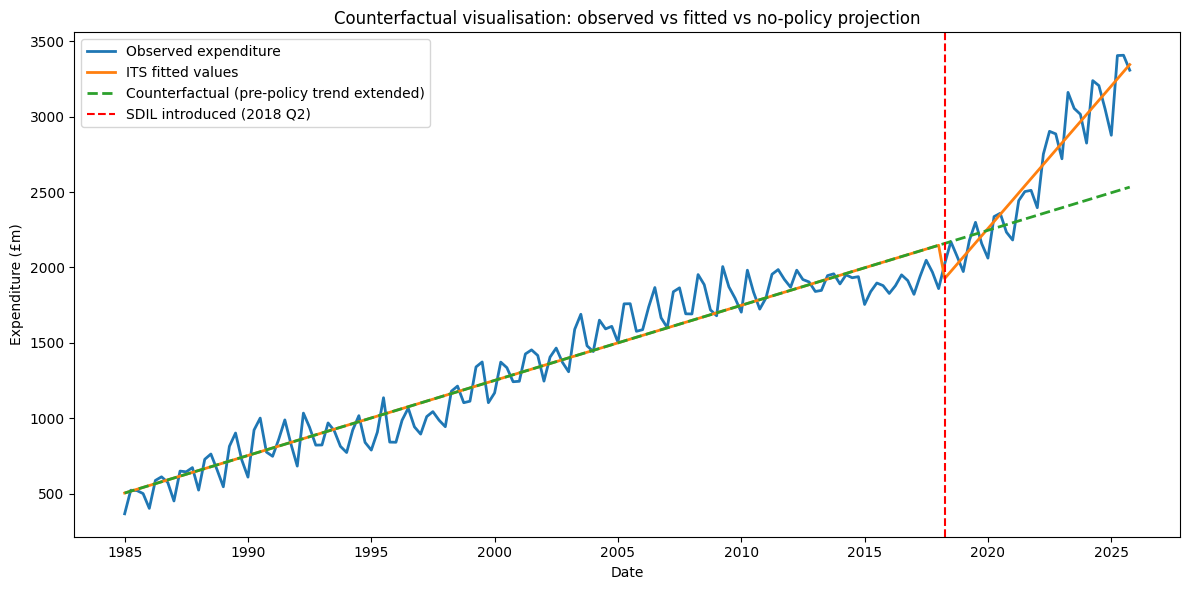

In [19]:
policy_date = pd.Timestamp("2018-04-01")

df_q["y_hat_its"] = model.predict(X)

pre = df_q[df_q.index < policy_date].copy()

X_pre = sm.add_constant(pre[["t"]])
y_pre = pre["soft_drinks_expenditure_m"]
model_pretrend = sm.OLS(y_pre, X_pre).fit()

X_full_trend = sm.add_constant(df_q[["t"]])
df_q["y_counterfactual"] = model_pretrend.predict(X_full_trend)

plt.figure(figsize=(12, 6))

plt.plot(df_q.index, df_q["soft_drinks_expenditure_m"], label="Observed expenditure", linewidth=2)
plt.plot(df_q.index, df_q["y_hat_its"], label="ITS fitted values", linewidth=2)
plt.plot(df_q.index, df_q["y_counterfactual"], label="Counterfactual (pre-policy trend extended)", linestyle="--", linewidth=2)

plt.axvline(policy_date, color="red", linestyle="--", label="SDIL introduced (2018 Q2)")

plt.title("Counterfactual visualisation: observed vs fitted vs no-policy projection")
plt.xlabel("Date")
plt.ylabel("Expenditure (£m)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Results

This section presents the estimated effects of the Soft Drinks Industry Levy (SDIL) using an interrupted time series (ITS) regression framework. The model is first estimated using ordinary least squares (OLS), followed by estimation with heteroskedasticity and autocorrelation‑consistent (HAC) standard errors. The purpose of reporting both is to demonstrate robustness and appropriate inference for quarterly time‑series data.

The estimated coefficients are identical under both specifications, as the HAC procedure adjusts only the estimated uncertainty of the coefficients rather than the fitted values themselves. However, standard errors are larger under HAC, resulting in more conservative statistical inference. Given the quarterly frequency of the data and the likelihood that household expenditure exhibits serial correlation over time, inference based on HAC standard errors is treated as the primary result.

Pre‑Intervention Trend

The coefficient on the linear time trend is positive and statistically significant under both conventional OLS and HAC inference. This indicates that household expenditure on soft drinks was increasing steadily prior to the introduction of the SDIL. This result is consistent with the patterns observed in the exploratory analysis, which showed strong upward growth in nominal expenditure over the long run.

Immediate Post‑Policy Level Change

The post‑intervention indicator is negative and statistically significant in both specifications. This suggests an immediate downward shift in the level of household soft drinks expenditure coinciding with the introduction of the SDIL in 2018 Q2, relative to what would have been expected given the pre‑policy trend. This short‑run reduction is consistent with behavioural adjustment at the time of policy implementation, potentially reflecting higher prices or changes in purchasing behaviour.

Post‑Policy Trend Change

The interaction term capturing the change in trend after the policy intervention is positive and statistically significant under both OLS and HAC standard errors. This indicates that, following the introduction of the SDIL, the growth rate of expenditure increased relative to the pre‑intervention period. As a result, although expenditure appears to have experienced an initial decline at the time of the levy’s introduction, it subsequently grew at a faster rate than before.

Robustness and Interpretation

Importantly, the direction, magnitude, and statistical significance of all key coefficients remain unchanged when moving from conventional OLS inference to HAC‑corrected standard errors. This robustness suggests that the results are not driven by overly optimistic standard errors arising from serial correlation in the residuals, and strengthens confidence in the estimated post‑policy dynamics.
Taken together, the results suggest that the introduction of the SDIL is associated with a short‑run reduction in household expenditure on soft drinks, followed by a period of faster subsequent growth. This pattern is consistent with the absence of a large or sustained visual break in the expenditure series observed in the exploratory analysis. Rather than producing a persistent decline in spending, the policy appears to have been associated with temporary adjustment effects and changes in expenditure growth over time.
It is important to note that this analysis focuses on nominal household expenditure and cannot directly distinguish between changes in prices, quantities purchased, or product reformulation. As such, the results should be interpreted as evidence of an association between the SDIL and expenditure patterns, rather than definitive causal effects on consumption or sugar intake.
